In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Modelling
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay,roc_curve, auc
from sklearn.model_selection import RandomizedSearchCV, train_test_split, validation_curve
from scipy.stats import randint


from sklearn.model_selection import RandomizedSearchCV

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,confusion_matrix, classification_report

from imblearn.ensemble import BalancedRandomForestClassifier
warnings.filterwarnings('ignore')

import pandas as pd

In [2]:
df = pd.read_stata('../../data/Politbarometer/dataset_cumul_1977_reduced.dta',convert_categoricals=False)
df



,index,v1,v2,Version,doi,v3,v4,V4a,v5,v6,...,v68,v71,v72,v73,v74,v75,v77,v78,v80,V81
0,345603,2391,2001.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,1,...,0,0,2,1,4,12,8,0.520,1,0.144
1,345604,2391,2002.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,2,...,0,0,10,0,4,12,8,0.550,1,0.153
2,345605,2391,2003.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,18,...,1,4,10,0,1,12,8,1.000,1,0.277
3,345607,2391,2011.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,6,...,0,0,8,2,4,17,7,0.640,1,0.178
4,345608,2391,2012.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,2,...,0,0,1,3,4,15,1,0.950,1,0.264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568019,1046811,2391,501623.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,2,...,0,4,1,3,1,8,4,0.917,50,0.917
568020,1046812,2391,501624.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,1,6,...,0,0,8,2,4,15,5,0.461,50,0.223
568021,1046815,2391,501627.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,4,...,0,4,6,2,3,1,1,0.596,50,0.596
568022,1046816,2391,501628.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,1,38,...,0,4,10,0,4,13,5,1.969,50,0.954


In [111]:
exclude = [f'v{i}' for i in [1,2] + list(range(8,18)) + list(range(46,48)) + list(range(54,71)) + list(range(78,82))] # exclure les méta données 
exclude_also = ['v7','v72','v22','index'] # exclure les méta données 
df_reduced = df[[column for column in df.columns if column not in ['Version','doi','V81'] + exclude + exclude_also]]

In [112]:
df_reduced

,v3,v4,V4a,v5,v6,v18,v21,v25,v27,v28,...,v34,v35,v36,v52,v53,v71,v73,v74,v75,v77
0,1,2000,1,1,1,2,0,4,2,3,...,53,0,1,4,0,0,1,4,12,8
1,1,2000,1,1,2,2,0,3,2,3,...,1,0,2,4,0,0,0,4,12,8
2,1,2000,1,1,18,2,0,3,3,4,...,19,0,5,4,0,4,0,1,12,8
3,1,2000,1,1,6,3,0,3,3,3,...,33,0,5,4,0,0,2,4,17,7
4,1,2000,1,1,2,3,0,4,2,3,...,14,0,2,2,3,0,3,4,15,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568019,12,2022,2,1,2,0,3,3,2,3,...,5,0,2,2,4,4,3,1,8,4
568020,12,2022,1,1,6,0,2,2,2,3,...,27,0,2,4,0,0,2,4,15,5
568021,12,2022,2,1,4,0,2,2,3,3,...,1,0,3,4,0,4,2,3,1,1
568022,12,2022,1,1,38,0,2,3,2,4,...,15,0,3,4,0,4,0,4,13,5


In [61]:
partie_codes = {
    1  : 'CDU',
    2  : 'SPD',
    3  : 'FDP',
    4  : 'Gruene',
    6  : 'Linke',
    8  : 'NPD',
    49 : 'AfD',
    97 : 'undecided'
}

In [ ]:
partie_code = 1
years = [year for year in range(2017,2020)]
target_question = 'v6'
model = 2

In [ ]:
# transform problem into binary classification problem
left = [2,4,6]
right = [1,3,8,49]
df_model_prep = df_reduced[df_reduced['v6'].isin(left + right)]
df_model_prep['v6'] = df_model_prep['v6'].apply(lambda f: f in left)

df_model_training = df_model_prep[(df_model_prep['v4'].isin(years))]
df_model_training = df_model_training.drop(['v3','v4'],axis=1)

df_model_training

,V4a,v5,v6,v18,v21,v25,v27,v28,v33,v34,v35,v36,v52,v53,v71,v73,v74,v75,v77
470424,2,1,False,0,3,2,2,4,54,23,1,1,2,3,4,0,1,3,5
470425,2,1,True,0,1,2,2,3,77,30,2,2,4,0,4,2,4,2,8
470426,1,1,False,0,2,2,2,3,108,54,1,1,2,6,0,2,1,17,1
470427,2,1,False,0,3,2,2,3,54,117,1,9,4,0,0,1,4,9,5
470429,2,1,False,0,3,3,2,3,27,54,9,9,1,3,4,3,4,5,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528292,2,1,True,0,2,3,2,3,15,77,3,3,2,6,4,2,4,3,8
528293,2,1,True,0,2,2,2,3,123,15,1,3,4,0,4,3,1,3,7
528294,2,1,True,0,2,3,2,3,58,15,1,1,2,3,4,2,4,9,1
528295,2,1,True,0,1,2,2,3,65,77,9,9,4,0,4,2,4,3,5


## Créer la courbe de validation

In [ ]:
X = df_model_training.drop([target_question], axis=1)
y = df_model_training[target_question]

In [65]:
param_range = np.arange(1, 100, 2)
# Calculate accuracy on training and test set using the validation curve
train_scores, test_scores = validation_curve(
    RandomForestClassifier(),
    X, y,   
    param_name="n_estimators",
    param_range=param_range,
    cv=4,
    scoring="accuracy",
    n_jobs=-1
)

In [68]:
train_scores_hgb, test_scores_hgb = validation_curve(
    HistGradientBoostingClassifier(),
    X, y,
    param_name="max_iter",
    param_range=param_range,
    cv=4,
    scoring="accuracy",
    n_jobs=-1
)

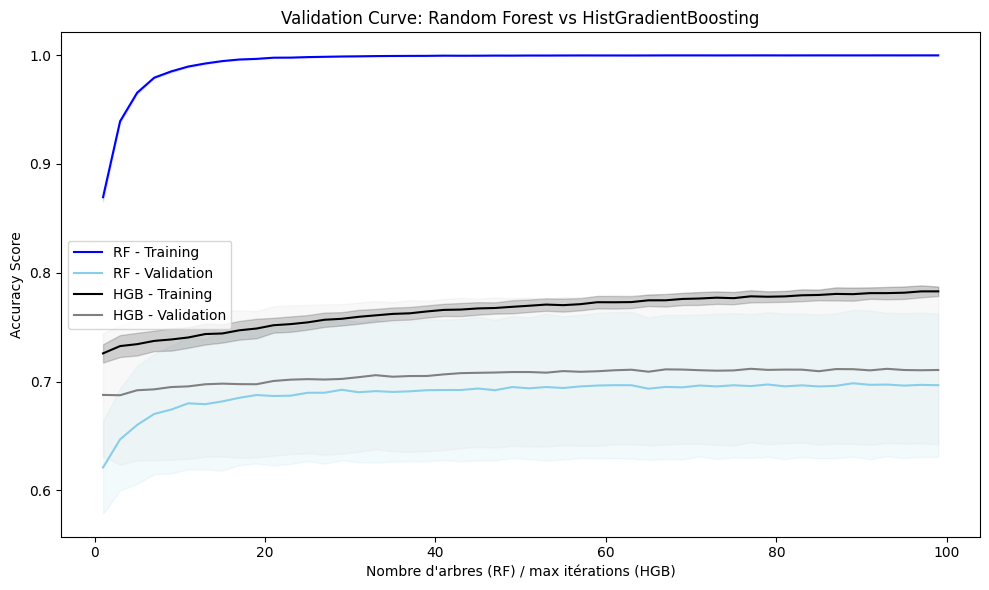

In [ ]:
# Random Forest
train_mean_rf = np.mean(train_scores, axis=1)
train_std_rf = np.std(train_scores, axis=1)
test_mean_rf = np.mean(test_scores, axis=1)
test_std_rf = np.std(test_scores, axis=1)

# HGB
train_mean_hgb = np.mean(train_scores_hgb, axis=1)
train_std_hgb = np.std(train_scores_hgb, axis=1)
test_mean_hgb = np.mean(test_scores_hgb, axis=1)
test_std_hgb = np.std(test_scores_hgb, axis=1)

plt.figure(figsize=(10, 6))

# Random Forest
plt.plot(param_range, train_mean_rf, label="RF - Training", color="blue")
plt.plot(param_range, test_mean_rf, label="RF - Validation", color="skyblue")
plt.fill_between(param_range, train_mean_rf - train_std_rf, train_mean_rf + train_std_rf, alpha=0.1, color="blue")
plt.fill_between(param_range, test_mean_rf - test_std_rf, test_mean_rf + test_std_rf, alpha=0.1, color="skyblue")

# HistGradientBoosting
plt.plot(param_range, train_mean_hgb, label="HGB - Training", color="black")
plt.plot(param_range, test_mean_hgb, label="HGB - Validation", color="gray")
plt.fill_between(param_range, train_mean_hgb - train_std_hgb, train_mean_hgb + train_std_hgb, alpha=0.2, color="black")
plt.fill_between(param_range, test_mean_hgb - test_std_hgb, test_mean_hgb + test_std_hgb, alpha=0.2, color="gainsboro")

plt.title("Validation Curve: Random Forest vs HistGradientBoosting")
plt.xlabel("Nombre d'arbres (RF) / max itérations (HGB)")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig('report/images/validation_curve_models.pdf',bbox_inches = 'tight')
plt.show()


## Entrainement du modèle sur les années 2000 à 2020


In [90]:
training_years = [year for year in range(2000,2021)]
df_model_training_rf = df_model_prep[(df_model_prep['v4'].isin(training_years))]
df_model_training_rf = df_model_training_rf.drop(['v3','v4'],axis=1)
X_train = df_model_training_rf.drop([target_question], axis=1)
y_train = df_model_training_rf[target_question]

In [101]:
training_years

[2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020]

In [91]:


# Paramètres à tester
param_dist = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 8],
    "max_iter": [20],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [10, 20, 50, 100],
    "l2_regularization": [0.0, 1.0, 5.0, 10.0],
    "early_stopping": [True]
}
# Randomized Search
hgb = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(),
    param_distributions=param_dist,
    n_iter=30,  # nombre d’échantillons testés
    cv=5,  # cross-validation à 5 plis
    verbose=1,
    random_state=42,
    n_jobs=-1,  # utilise tous les cœurs du CPU
    scoring='accuracy'  # ou 'roc_auc', etc.
)

# Lancement
hgb.fit(X_train, y_train)

# Résultats
print("Meilleurs paramètres :", hgb.best_params_)
print("Meilleur score CV :", hgb.best_score_)
print(hgb.best_estimator_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs paramètres : {'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'max_iter': 20, 'max_depth': 8, 'learning_rate': 0.2, 'l2_regularization': 5.0, 'early_stopping': True}
Meilleur score CV : 0.775284205333116
HistGradientBoostingClassifier(early_stopping=True, l2_regularization=5.0,
                               learning_rate=0.2, max_depth=8, max_iter=20)


In [92]:
param_dist = {
    "n_estimators": [20],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}
# RandomizedSearch
rf = RandomizedSearchCV(
    estimator=BalancedRandomForestClassifier(),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='roc_auc'  # très utile pour les données déséquilibrées
)

# Entraînement
rf.fit(X_train, y_train)



Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5, estimator=BalancedRandomForestClassifier(), n_iter=30,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 5],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [20]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [93]:
# Résultats
print("Meilleurs paramètres :", rf.best_params_)
print("Score ROC AUC CV :", rf.best_score_)

Meilleurs paramètres : {'n_estimators': 20, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}
Score ROC AUC CV : 0.8478599559789505


In [94]:
rf = RandomForestClassifier(
    n_estimators=20,
    min_samples_split=2,
    min_samples_leaf=5,
    max_features='log2',
    max_depth=20,
    bootstrap=False,
    random_state=42  # Optionnel pour reproductibilité
)
rf.fit(X_train,y_train)


RandomForestClassifier(bootstrap=False, max_depth=20, max_features='log2',
                       min_samples_leaf=5, n_estimators=20, random_state=42)

In [ ]:
hgb.fit(X_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5, estimator=HistGradientBoostingClassifier(), n_iter=30,
                   n_jobs=-1,
                   param_distributions={'early_stopping': [True],
                                        'l2_regularization': [0.0, 1.0, 5.0,
                                                              10.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 8],
                                        'max_iter': [20],
                                        'max_leaf_nodes': [15, 31, 63],
                                        'min_samples_leaf': [10, 20, 50, 100]},
                   random_state=42, scoring='accuracy', verbose=1)

## Tester sur les données de l'année 2021
Le modèle a été entraîné sur le jeu de données des années 2000 à 2020, nous vérifions sa performance avec le jeu de données des années 2021

In [103]:
test_years = [2021]
# transform problem into binary classification problem
df_model_test = df_model_prep[(df_model_prep['v4'].isin(test_years))]
df_model_test = df_model_test.drop(['v3','v4'],axis=1)
X_test = df_model_test.drop([target_question], axis=1)
y_test = df_model_test[target_question]


In [104]:
y_pred_rf = rf.predict_proba(X_test)[:, 1]
y_pred_hgb = hgb.predict_proba(X_test)[:,1]
test_df = pd.DataFrame(
    {'True': list(y_test), 'RF':y_pred_rf, 'HGB': y_pred_hgb})
y_pred_rf

array([0.39373377, 0.10376486, 0.79693761, ..., 0.95190476, 0.95197421,
       0.94047619])

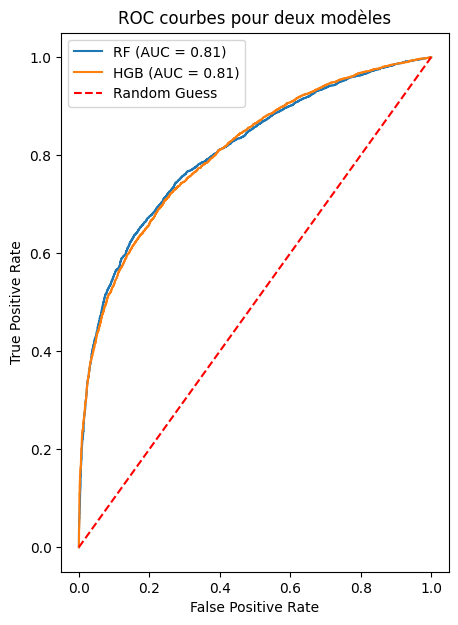

In [109]:
plt.figure(figsize=(5, 7))

for model in ['RF', 'HGB']:
    fpr, tpr, _ = roc_curve(test_df['True'], test_df[model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC courbes pour deux modèles')
plt.legend()
plt.savefig('report/images/roc_curve.pdf', bbox_inches='tight')
plt.show()

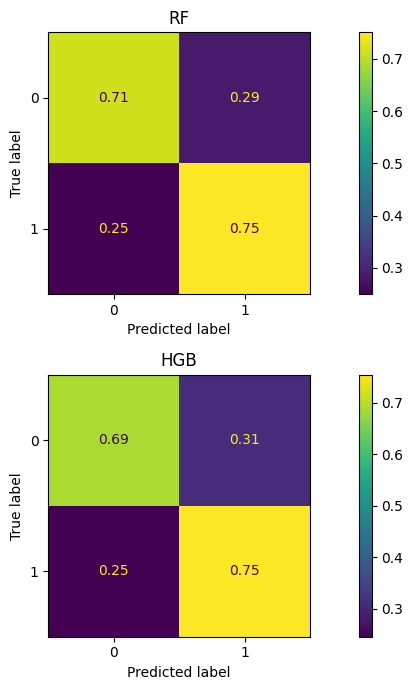

In [ ]:
y_pred_rf_all = rf.predict(X_test)
y_pred_hgb_all = hgb.predict(X_test)
titles = ['RF', 'HGB']
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10,7))
classifiers = [y_pred_rf_all, y_pred_hgb_all]
for i,(cls, ax) in enumerate(zip(classifiers, axes.flatten())):
    ConfusionMatrixDisplay(confusion_matrix(y_test, cls,normalize='true')).plot(ax=ax)
    ax.title.set_text(titles[i])
plt.tight_layout()  
plt.savefig('../../report/images/matrices_confusion_deux_modeles.pdf', bbox_inches='tight')

plt.show()

In [107]:
y_pred_rf = rf.predict(X_test)
y_pred_hgb = hgb.predict(X_test)
print(classification_report(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_hgb))


              precision    recall  f1-score   support

       False       0.71      0.71      0.71      4699
        True       0.75      0.75      0.75      5444

    accuracy                           0.73     10143
   macro avg       0.73      0.73      0.73     10143
weighted avg       0.73      0.73      0.73     10143

              precision    recall  f1-score   support

       False       0.71      0.69      0.70      4699
        True       0.74      0.75      0.75      5444

    accuracy                           0.72     10143
   macro avg       0.72      0.72      0.72     10143
weighted avg       0.72      0.72      0.72     10143



In [108]:
# Extract feature importances
importances = rf.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Rank features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

# Select top N features (example selecting top 10 features)
top_features = feature_importance_df['Feature'][:10].values
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

   Feature  Importance
10     v36    0.408472
9      v35    0.235757
8      v34    0.044738
7      v33    0.043384
12     v53    0.034596
16     v75    0.032365
17     v77    0.030353
14     v73    0.026988
11     v52    0.025533
15     v74    0.023704
3      v21    0.020693
4      v25    0.017021
6      v28    0.014981
13     v71    0.014615
5      v27    0.012115
2      v18    0.009366
0      V4a    0.003982
1       v5    0.001339
